# P706 – World Development Measurement: Cluster Analysis

**Business Objective:** Create clusters on the global development measurement dataset, perform comparative analysis using different clustering models, and prepare the solution for deployment.

The source document specifies the stages **EDA → Model Building → Deployment → Final Presentation** and asks for different clustering models with comparative analysis.

## 1. Install / Import Libraries

In [1]:
# Run this once in Jupyter if required:
# !pip install pandas numpy scikit-learn matplotlib openpyxl joblib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Load the Excel Dataset

In [2]:
file_path = "P706_ World_development_mesurement.xlsx"
sheet_name = "world_development"

df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())


Dataset shape: (2704, 25)

First 5 rows:


,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.0200,NaN,"87,931.0000",Algeria,NaN,NaN,"26,998.0000","$54,790,058,957",0.0350,$60,NaN,0.0340,0.0000,0.1000,71.0000,67.0000,0.0000,1,0.3420,0.6190,0.0390,31719449,0.5990,"$102,000,000","$193,000,000"
1,0.0500,NaN,"9,542.0000",Angola,NaN,NaN,"7,499.0000","$9,129,594,819",0.0340,$22,NaN,0.1280,0.0000,1.0320,47.0000,44.0000,0.0000,1,0.4760,0.4990,0.0250,13924930,0.3240,"$34,000,000","$146,000,000"
2,0.0430,NaN,"1,617.0000",Benin,NaN,NaN,"1,983.0000","$2,359,122,303",0.0430,$15,NaN,0.0900,0.0000,NaN,57.0000,53.0000,0.0000,1,0.4540,0.5170,0.0290,6949366,0.3830,"$77,000,000","$50,000,000"
3,0.0270,NaN,"4,276.0000",Botswana,NaN,NaN,"1,836.0000","$5,788,311,645",0.0470,$152,NaN,0.0540,0.0000,0.1550,52.0000,49.0000,0.1000,1,0.3830,0.5870,0.0290,1755375,0.5320,"$227,000,000","$209,000,000"
4,0.0460,NaN,"1,041.0000",Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.0510,$12,NaN,0.0960,0.0000,NaN,52.0000,49.0000,0.0000,1,0.4680,0.5050,0.0280,11607944,0.1780,"$23,000,000","$30,000,000"


## 3. Understand the Dataset

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())
print("Unique countries:", df["Country"].nunique())


Columns:
['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Country', 'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP', 'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate', 'Internet Usage', 'Lending Interest', 'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage', 'Number of Records', 'Population 0-14', 'Population 15-64', 'Population 65+', 'Population Total', 'Population Urban', 'Tourism Inbound', 'Tourism Outbound']

Data types:


,dtype
Birth Rate,float64
Business Tax Rate,object
CO2 Emissions,float64
Country,object
Days to Start Business,float64
Ease of Business,float64
Energy Usage,float64
GDP,object
Health Exp % GDP,float64
Health Exp/Capita,object



Missing values:


,missing_count
Ease of Business,2519
Hours to do Tax,1288
Business Tax Rate,1281
Days to Start Business,986
Energy Usage,919
Lending Interest,824
CO2 Emissions,579
Tourism Outbound,471
Tourism Inbound,368
Health Exp/Capita,309



Duplicate rows: 0
Unique countries: 208


## 4. Convert Text-Based Numeric Columns

In [4]:
# These columns are stored as text because of $, %, and comma formatting.
text_numeric_cols = [
    "Business Tax Rate",
    "GDP",
    "Health Exp/Capita",
    "Tourism Inbound",
    "Tourism Outbound"
]

for col in text_numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(r"[$,%]", "", regex=True),
        errors="coerce"
    )

print("Converted columns:")
display(df[text_numeric_cols].head())


Converted columns:


,Business Tax Rate,GDP,Health Exp/Capita,Tourism Inbound,Tourism Outbound
0,NaN,"54,790,058,957.0000",60.0000,"102,000,000.0000","193,000,000.0000"
1,NaN,"9,129,594,819.0000",22.0000,"34,000,000.0000","146,000,000.0000"
2,NaN,"2,359,122,303.0000",15.0000,"77,000,000.0000","50,000,000.0000"
3,NaN,"5,788,311,645.0000",152.0000,"227,000,000.0000","209,000,000.0000"
4,NaN,"2,610,959,139.0000",12.0000,"23,000,000.0000","30,000,000.0000"


## 5. Basic EDA – Summary Statistics

In [5]:
numeric_df = df.select_dtypes(include=np.number)

print("Numeric columns:", len(numeric_df.columns))
display(numeric_df.describe().T)


Numeric columns: 24


,count,mean,std,min,25%,50%,75%,max
Birth Rate,"2,585.0000",0.0227,0.0113,0.0070,0.0130,0.0200,0.0310,0.0530
Business Tax Rate,"1,423.0000",48.9669,40.9541,8.2000,32.4000,41.0000,51.5500,339.1000
CO2 Emissions,"2,125.0000","142,307.1078","615,928.8057",7.0000,"1,360.0000","8,529.0000","59,108.0000","8,286,892.0000"
Days to Start Business,"1,718.0000",39.9994,57.3186,1.0000,13.0000,26.0000,45.0000,694.0000
Ease of Business,185.0000,94.8757,54.7919,1.0000,48.0000,94.0000,142.0000,189.0000
Energy Usage,"1,785.0000","77,236.8409","259,923.8558",8.0000,"3,737.0000","14,338.0000","41,852.0000","2,727,728.0000"
GDP,"2,494.0000","263,854,042,324.2658","1,129,910,323,899.1589","63,101,272.0000","3,539,042,240.7500","15,079,752,557.5000","110,204,692,644.0000","16,244,600,000,000.0000"
Health Exp % GDP,"2,395.0000",0.0642,0.0263,0.0080,0.0460,0.0610,0.0790,0.2250
Health Exp/Capita,"2,395.0000",801.3971,"1,473.4480",2.0000,50.0000,193.0000,665.0000,"9,908.0000"
Hours to do Tax,"1,416.0000",302.0685,273.2997,12.0000,156.0000,239.0000,344.7500,"2,600.0000"


## 6. EDA – Missing Values

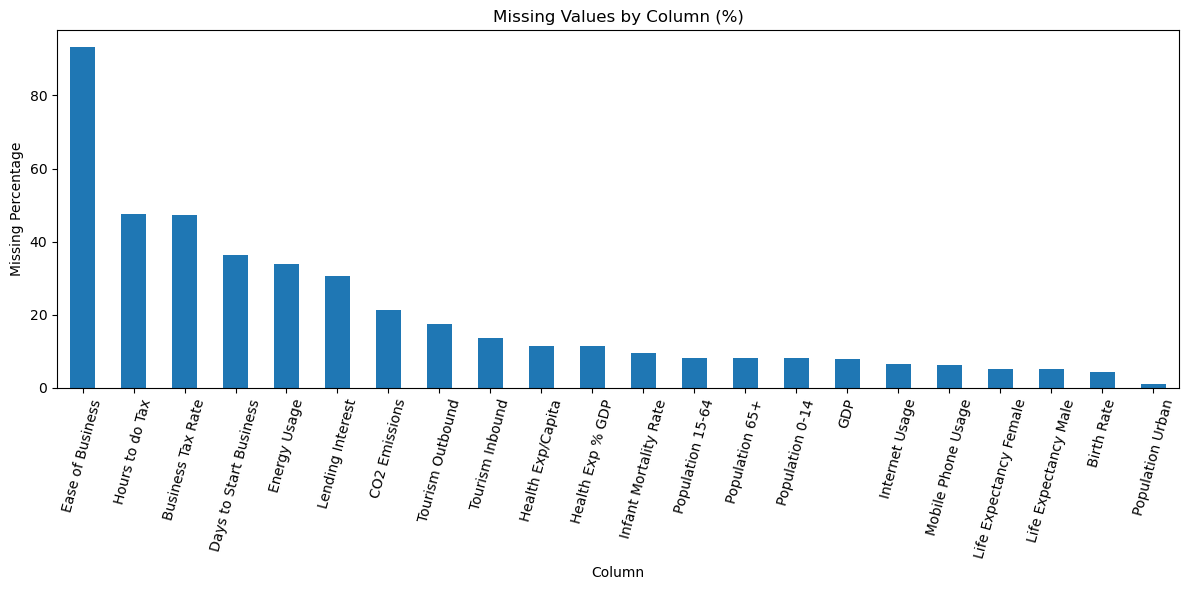

In [6]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
missing_pct[missing_pct > 0].plot(kind="bar")
plt.title("Missing Values by Column (%)")
plt.xlabel("Column")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## 7. EDA – Selected Distributions

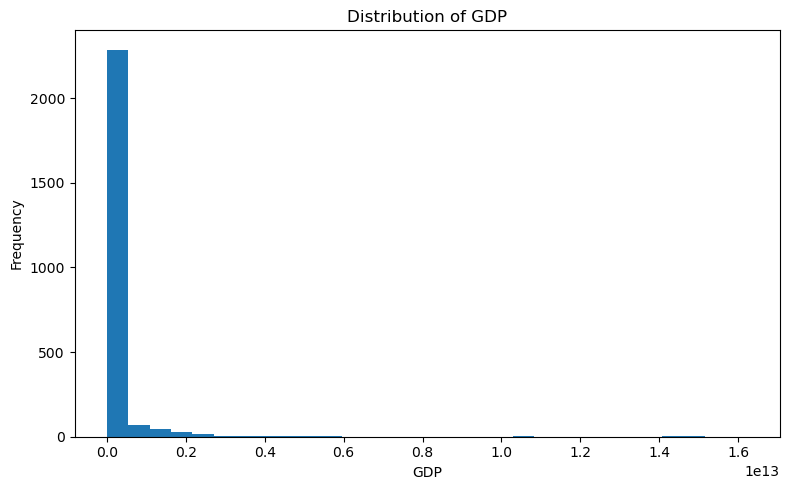

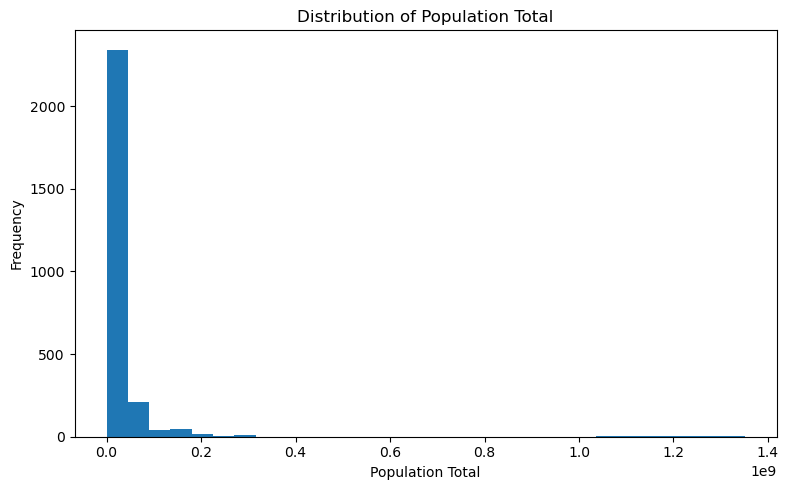

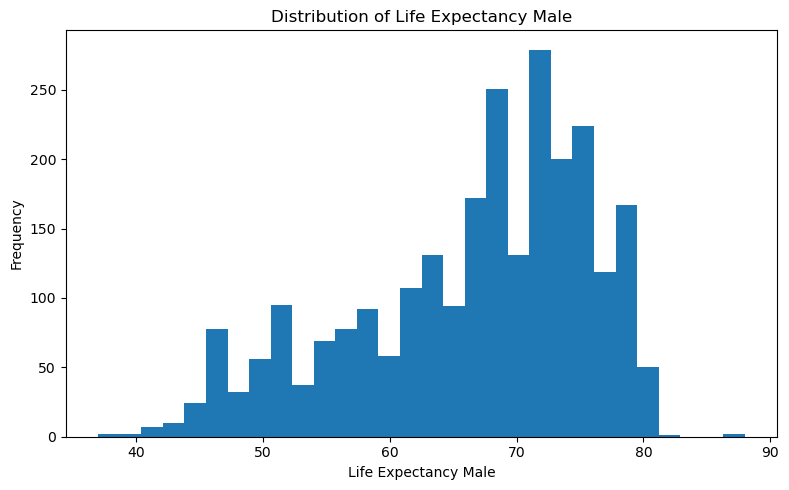

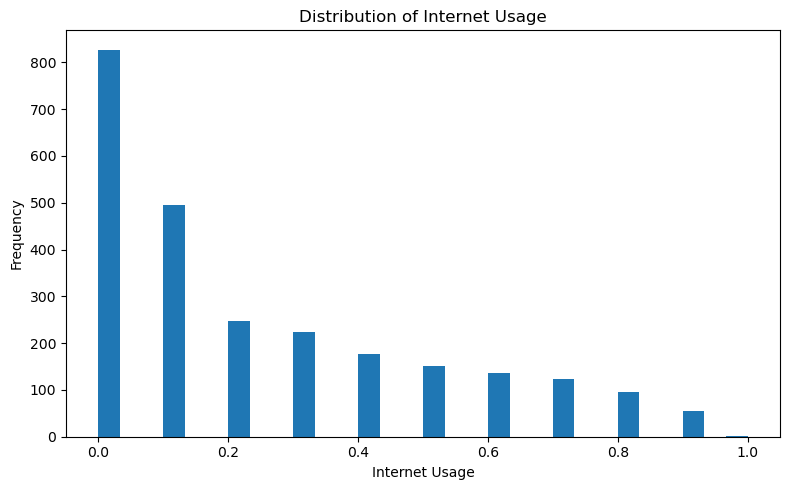

In [7]:
for col in ["GDP", "Population Total", "Life Expectancy Male", "Internet Usage"]:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## 8. Select Features for Clustering

In [8]:
# Country is an identifier, so it is not used as a clustering feature.
# Number of Records is constant in this dataset, so it is also excluded.

features = [
    col for col in df.columns
    if col not in ["Country", "Number of Records"]
]

X = df[features].copy()

# Ensure all features are numeric.
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

print("Number of clustering features:", len(features))
print(features)


Number of clustering features: 23
['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP', 'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate', 'Internet Usage', 'Lending Interest', 'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage', 'Population 0-14', 'Population 15-64', 'Population 65+', 'Population Total', 'Population Urban', 'Tourism Inbound', 'Tourism Outbound']


## 9. Missing-Value Imputation and Feature Scaling

In [9]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

print("Processed matrix shape:", X_scaled.shape)


Processed matrix shape: (2704, 23)


## 10. K-Means – Elbow Method

  File "C:\Users\WAKIL AHMED ANSARI\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\WAKIL AHMED ANSARI\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\WAKIL AHMED ANSARI\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C

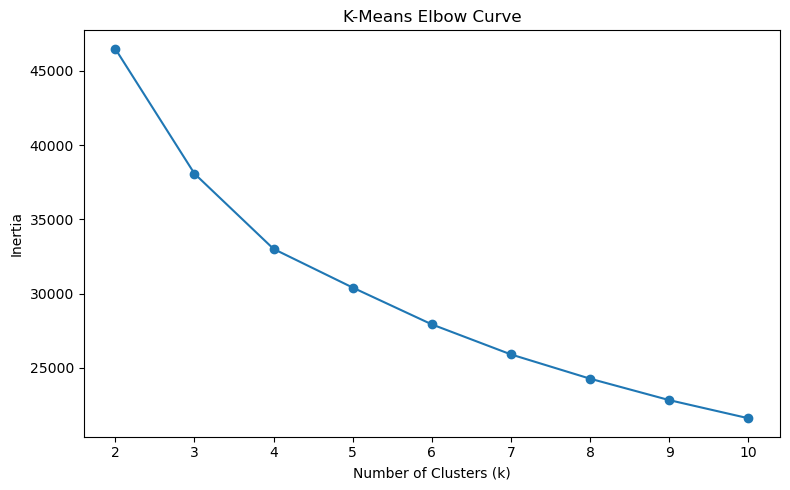

In [10]:
k_values = range(2, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("K-Means Elbow Curve")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


## 11. K-Means – Silhouette Analysis and Select k

,k,silhouette_score
0,2,0.2869
1,3,0.3056
2,4,0.2563
3,5,0.2632
4,6,0.2033
5,7,0.2173
6,8,0.2209
7,9,0.2222
8,10,0.2187


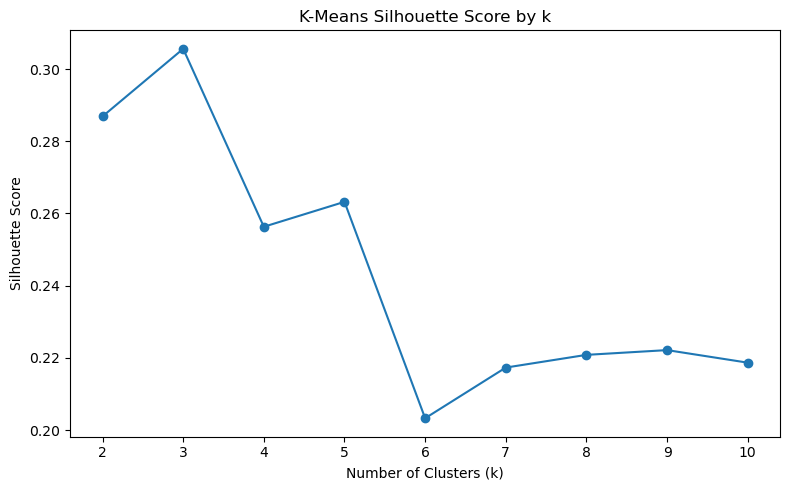

Selected k based on highest silhouette score: 3


In [11]:
silhouette_by_k = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_by_k.append(score)

silhouette_table = pd.DataFrame({
    "k": list(k_values),
    "silhouette_score": silhouette_by_k
})

display(silhouette_table)

plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_table["k"],
    silhouette_table["silhouette_score"],
    marker="o"
)
plt.title("K-Means Silhouette Score by k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

best_k = int(
    silhouette_table.loc[
        silhouette_table["silhouette_score"].idxmax(), "k"
    ]
)

print("Selected k based on highest silhouette score:", best_k)


## 12. Build K-Means Model

In [12]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means cluster counts:")
display(pd.Series(kmeans_labels).value_counts().sort_index())


K-Means cluster counts:


0    1057
1    1621
2      26
Name: count, dtype: int64

## 13. Build Agglomerative Hierarchical Clustering

In [13]:
hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

print("Agglomerative cluster counts:")
display(pd.Series(hierarchical_labels).value_counts().sort_index())


Agglomerative cluster counts:


0    2015
1     650
2      39
Name: count, dtype: int64

## 14. Build Gaussian Mixture Model (GMM)

In [14]:
gmm = GaussianMixture(
    n_components=best_k,
    random_state=42,
    n_init=10
)

gmm_labels = gmm.fit_predict(X_scaled)

print("GMM cluster counts:")
display(pd.Series(gmm_labels).value_counts().sort_index())


GMM cluster counts:


0    1143
1      90
2    1471
Name: count, dtype: int64

## 15. DBSCAN – Parameter Search

In [15]:
dbscan_results = []

for eps in np.arange(0.8, 2.61, 0.2):
    for min_samples in [5, 10, 20]:
        db = DBSCAN(eps=float(eps), min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        non_noise = labels != -1
        n_clusters = len(set(labels[non_noise]))
        noise_pct = (~non_noise).mean() * 100

        if n_clusters >= 2 and non_noise.sum() > n_clusters and noise_pct <= 80:
            sil = silhouette_score(X_scaled[non_noise], labels[non_noise])
            dbi = davies_bouldin_score(X_scaled[non_noise], labels[non_noise])
            chi = calinski_harabasz_score(X_scaled[non_noise], labels[non_noise])

            dbscan_results.append({
                "eps": round(float(eps), 2),
                "min_samples": min_samples,
                "clusters": n_clusters,
                "noise_pct": noise_pct,
                "silhouette": sil,
                "davies_bouldin": dbi,
                "calinski_harabasz": chi
            })

dbscan_table = pd.DataFrame(dbscan_results)

if dbscan_table.empty:
    print("No suitable DBSCAN parameter combination was found.")
    dbscan = DBSCAN(eps=1.5, min_samples=10)
    dbscan_labels = dbscan.fit_predict(X_scaled)
else:
    display(
        dbscan_table
        .sort_values("silhouette", ascending=False)
        .head(10)
    )

    best_dbscan_params = (
        dbscan_table
        .sort_values("silhouette", ascending=False)
        .iloc[0]
    )

    dbscan = DBSCAN(
        eps=float(best_dbscan_params["eps"]),
        min_samples=int(best_dbscan_params["min_samples"])
    )
    dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN label counts:")
display(pd.Series(dbscan_labels).value_counts().sort_index())


,eps,min_samples,clusters,noise_pct,silhouette,davies_bouldin,calinski_harabasz
19,2.6000,10,3,6.6938,0.4094,0.5662,64.3664
0,0.8000,5,142,54.2160,0.4054,0.7889,194.9720
5,1.2000,20,3,68.2322,0.3434,0.9861,841.0301
2,1.0000,10,13,74.4822,0.2102,0.9838,204.6000
13,2.0000,10,6,14.6080,0.1950,0.6989,57.0281
17,2.4000,10,7,8.0621,0.1065,0.8182,57.6049
18,2.6000,5,16,2.4778,0.1029,0.5833,69.9172
15,2.2000,10,7,10.3180,0.0970,0.8402,57.8916
16,2.4000,5,19,2.9956,0.0614,0.6216,64.7796
1,1.0000,5,106,33.0251,0.0288,0.9941,60.6143


DBSCAN label counts:


-1     181
 0    2500
 1      12
 2      11
Name: count, dtype: int64

## 16. Comparative Analysis of Clustering Models

In [16]:
def clustering_metrics(X_data, labels):
    labels = np.asarray(labels)
    mask = labels != -1  # remove DBSCAN noise for internal metrics

    X_eval = X_data[mask]
    y_eval = labels[mask]

    n_clusters = len(np.unique(y_eval))

    if n_clusters < 2:
        return {
            "Clusters": n_clusters,
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan,
            "Noise_%": round((1 - mask.mean()) * 100, 2)
        }

    return {
        "Clusters": n_clusters,
        "Silhouette": silhouette_score(X_eval, y_eval),
        "Davies_Bouldin": davies_bouldin_score(X_eval, y_eval),
        "Calinski_Harabasz": calinski_harabasz_score(X_eval, y_eval),
        "Noise_%": round((1 - mask.mean()) * 100, 2)
    }

comparison = pd.DataFrame({
    "KMeans": clustering_metrics(X_scaled, kmeans_labels),
    "Agglomerative": clustering_metrics(X_scaled, hierarchical_labels),
    "GMM": clustering_metrics(X_scaled, gmm_labels),
    "DBSCAN": clustering_metrics(X_scaled, dbscan_labels)
}).T

display(comparison.sort_values("Silhouette", ascending=False))


,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Noise_%
DBSCAN,3.0000,0.4094,0.5662,64.3664,6.6900
KMeans,3.0000,0.3056,1.0934,855.2108,0.0000
Agglomerative,3.0000,0.2990,1.1357,677.1587,0.0000
GMM,3.0000,0.1278,1.8102,445.6531,0.0000


## 17. PCA Visualization of Clusters

Explained variance ratio: [0.37399241 0.17196794]
Total explained variance: 0.5459603513371372


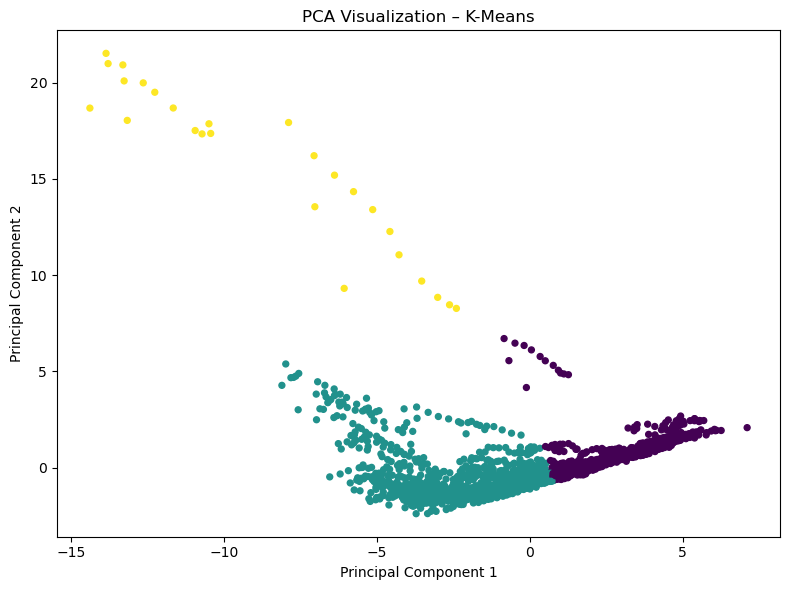

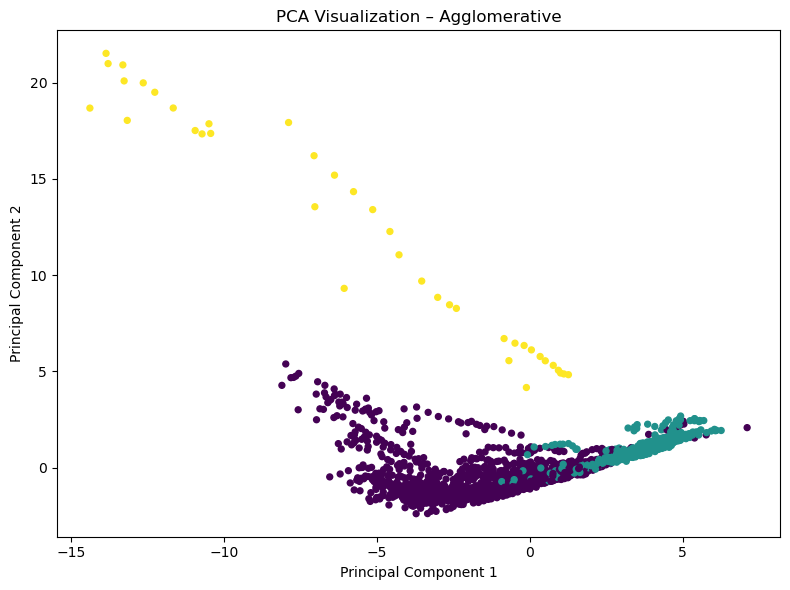

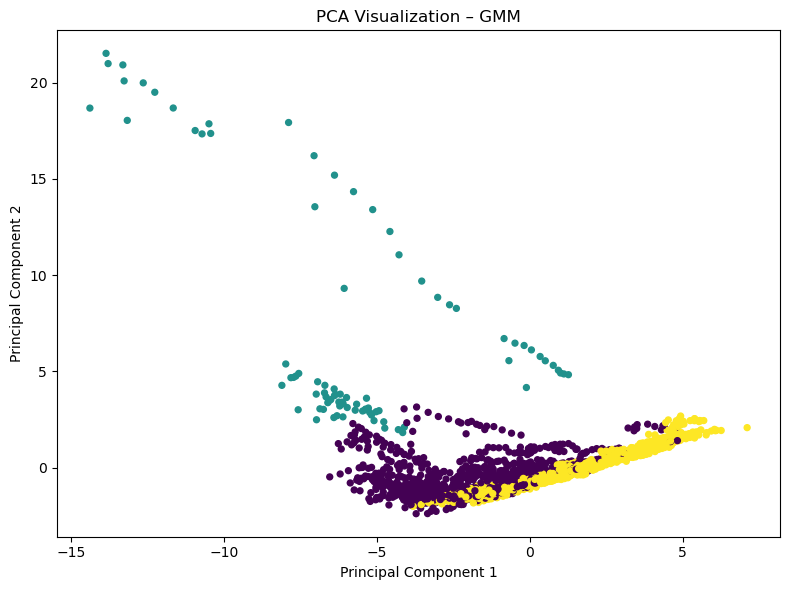

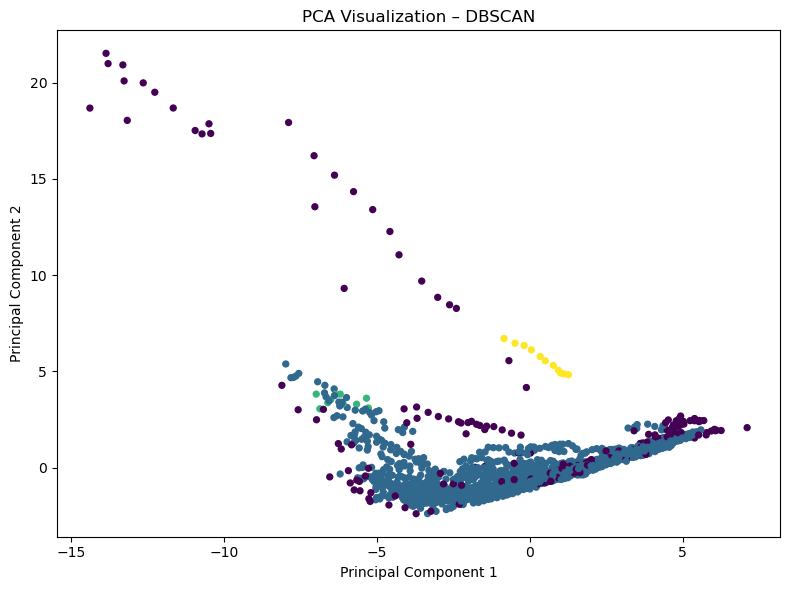

In [17]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

visual_sets = {
    "K-Means": kmeans_labels,
    "Agglomerative": hierarchical_labels,
    "GMM": gmm_labels,
    "DBSCAN": dbscan_labels
}

for model_name, labels in visual_sets.items():
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=18)
    plt.title(f"PCA Visualization – {model_name}")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.tight_layout()
    plt.show()


## 18. Add Cluster Labels to the Original Dataset

In [18]:
clustered_df = df.copy()

clustered_df["KMeans_Cluster"] = kmeans_labels
clustered_df["Agglomerative_Cluster"] = hierarchical_labels
clustered_df["GMM_Cluster"] = gmm_labels
clustered_df["DBSCAN_Cluster"] = dbscan_labels

display(
    clustered_df[
        ["Country", "KMeans_Cluster", "Agglomerative_Cluster", "GMM_Cluster", "DBSCAN_Cluster"]
    ].head(20)
)


,Country,KMeans_Cluster,Agglomerative_Cluster,GMM_Cluster,DBSCAN_Cluster
0,Algeria,0,0,0,0
1,Angola,0,1,2,-1
2,Benin,0,1,2,0
3,Botswana,0,1,2,0
4,Burkina Faso,0,1,2,0
5,Burundi,0,1,2,0
6,Cameroon,0,1,2,0
7,Central African Republic,0,1,2,0
8,Chad,0,1,2,0
9,Comoros,0,1,2,0


## 19. Profile the K-Means Clusters

In [19]:
profile_features = [
    col for col in features
    if pd.api.types.is_numeric_dtype(clustered_df[col])
]

cluster_profile = (
    clustered_df
    .groupby("KMeans_Cluster")[profile_features]
    .mean()
    .T
)

display(cluster_profile)


KMeans_Cluster,0,1,2
Birth Rate,0.0339,0.0150,0.0130
Business Tax Rate,59.2086,41.8378,59.2188
CO2 Emissions,"39,092.4850","118,582.6331","5,665,634.0909"
Days to Start Business,54.2323,30.2157,22.8500
Ease of Business,143.2424,68.3333,51.5000
Energy Usage,"28,638.0182","59,940.0555","2,053,691.9200"
GDP,"33,482,414,113.7367","278,597,529,004.2814","8,461,556,420,489.5000"
Health Exp % GDP,0.0576,0.0684,0.1046
Health Exp/Capita,75.8658,"1,297.9184","3,549.7308"
Hours to do Tax,318.2165,289.1899,398.5000


## 20. Show Countries in Each K-Means Cluster

In [20]:
for cluster_id in sorted(clustered_df["KMeans_Cluster"].unique()):
    print(f"\nCluster {cluster_id}")
    display(
        clustered_df.loc[
            clustered_df["KMeans_Cluster"] == cluster_id,
            ["Country", "KMeans_Cluster"]
        ].head(25)
    )



Cluster 0


,Country,KMeans_Cluster
0,Algeria,0
1,Angola,0
2,Benin,0
3,Botswana,0
4,Burkina Faso,0
5,Burundi,0
6,Cameroon,0
7,Central African Republic,0
8,Chad,0
9,Comoros,0



Cluster 1


,Country,KMeans_Cluster
26,Libya,1
31,Mauritius,1
40,Seychelles,1
49,Tunisia,1
54,Armenia,1
58,Brunei Darussalam,1
61,Georgia,1
62,"Hong Kong SAR, China",1
65,Japan,1
67,"Korea, Dem. Rep.",1



Cluster 2


,Country,KMeans_Cluster
60,China,2
204,United States,2
268,China,2
412,United States,2
476,China,2
620,United States,2
684,China,2
828,United States,2
892,China,2
1036,United States,2


## 21. Export Clustered Data

In [21]:
clustered_df.to_csv(
    "world_development_clustered.csv",
    index=False
)

print("Saved: world_development_clustered.csv")


Saved: world_development_clustered.csv


## 22. Save the K-Means Preprocessing + Model

In [22]:
model_bundle = {
    "features": features,
    "imputer": imputer,
    "scaler": scaler,
    "kmeans": kmeans
}

joblib.dump(
    model_bundle,
    "world_development_kmeans_model.pkl"
)

print("Saved: world_development_kmeans_model.pkl")


Saved: world_development_kmeans_model.pkl


## 23. Project Conclusion

The project is completed in the requested stages:

- **EDA:** structure, data types, missing values, distributions, and preprocessing.
- **Model Building:** K-Means, Agglomerative Hierarchical Clustering, GMM, and DBSCAN.
- **Comparative Analysis:** Silhouette, Davies–Bouldin, Calinski–Harabasz, and DBSCAN noise percentage.
- **Deployment Preparation:** clustered dataset, model bundle, and a Streamlit application.
